In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, BaseSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
from sidm.tools.llpnanoaodschema import LLPNanoAODSchema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import awkward as ak

In [2]:
samples = ["2Mu2E_200GeV_5p0GeV_20p0mm"]
fileset = utilities.make_fileset(samples[0:1], 
                                 "llpNanoAOD_v2", 
                                 location_cfg="signal_2mu2e_v10.yaml",
                                 max_files = 1,
                                )
fileset

{'2Mu2E_200GeV_5p0GeV_20p0mm': {'files': ['root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3_part-0.root'],
  'metadata': {'skim_factor': 1.0}}}

In [3]:
channels = ["base"]  # "baseNoLjNoLjsource", "baseNoLj", "base_ljObjCut", "base",
print(f"Running on sample: {samples[0]}")

Running on sample: 2Mu2E_200GeV_5p0GeV_20p0mm


In [4]:
p_skim = sidm_processor.SidmProcessor(
    channel_names=channels,
    hist_collection_names=["lj_base"],
    lj_reco_choices=["0.4"],
    skim_mode=True,
    verbose=True
)

print("Starting Skim Run...")
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True
)

# Run the processor
output = runner(fileset, treename="Events", processor_instance=p_skim)
dataset_key = list(output.keys())[0]
results = output[dataset_key]
results_original = results

print(output)

Output()

Starting Skim Run...


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

...

Applying ljs mu_charge == 0

Applying cut: pass triggers

Applying cut: PV filter

Applying cut: >=2 LJs

Signal not in xs cfg, assuming 1fb
{'2Mu2E_200GeV_5p0GeV_20p0mm': {'cutflow': {'base': <sidm.tools.cutflow.Cutflow object at 0x7fb3797b2990>}, 'hists': {'lj_n': <sidm.tools.histogram.Histogram object at 0x7fb35aea2240>, 'lj_pt': <sidm.tools.histogram.Histogram object at 0x7fb35aea12e0>, 'lj_eta_phi': <sidm.tools.histogram.Histogram object at 0x7fb378aeea50>, 'lj0_pt': <sidm.tools.histogram.Histogram object at 0x7fb378aeeba0>, 'lj1_pt': <sidm.tools.histogram.Histogram object at 0x7fb35ae6be60>, 'lj0_e': <sidm.tools.histogram.Histogram object at 0x7fb35ae69220>, 'lj1_e': <sidm.tools.histogram.Histogram object at 0x7fb35ae684d0>, 'lj0_dRSpread': <sidm.tools.histogram.Histogram object at 0x7fb35ae695e0>, 'lj1_dRSpread': <sidm.tools.histogram.Histogram object at 0x7fb35ae68e60>, 'lj_electronN': <sidm.tools.histogram.Histogram object at 0x7fb35ae68fe0>, 'lj_photonN': <sidm.tools.histogram.Histogram object at 0x7fb35aeb9160>, 'lj_electronPhotonN': <sidm.tools.histogram.Histogram object at 0x7

In [5]:
print(results_original.keys())
print(results_original['cutflow']['base'].print_table())
print()

print(results_original.keys())
print(results_original['cutflow']['base'].print_table(unweighted=True))
print()


for key in results_original["counters"]['0.4']['base'].keys():
    print(key, results_original["counters"]['0.4']['base'][key].value)
print()

print(results_original['hists'].keys())
import mplhep as hep
hist_list = []
hist_obj = results_original['hists']["lj_pt"]
hist_data = hist_obj.hist
hist_1d = hist_data[channels[0], :] 
hist_list.append(hist_1d)

# plt.subplots(1,1,figsize=(6,6))
# plt.subplot(1,1,1)
# hep.histplot(hist_list) 
# plt.legend(["base (Yes CC) Pre"])
# plt.show()

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                 59.8         59.8
pass triggers                17.4         17.4
PV filter                    59.8         17.4
>=2 LJs                      33.8         11.8
None

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection               1609.0       1609.0
pass triggers               469.0        469.0
PV filter                  1609.0        469.0
>=2 LJs                     908.0        316.0
None

Total LJs 633
Gen As to muons 316
Gen As to electrons 316
Matched gen As to muons 315
Matched gen As to electrons 316

dict_keys(['lj_n', 'lj_pt', 'lj_eta_phi', 'lj0_pt', 'lj1_pt', 'lj0_e', 'lj1_e', 'lj0_dRSpread', 'lj1_dRSpread', 'lj_electronN', 'lj_photonN', 'lj_electronPhotonN', 'lj_muonN',

In [6]:
results_original["metadata"]

{'n_evts': value_accumulator(int, 1609),
 'scaled_sum_weights': value_accumulator(float, np.float32(1609.0))}

In [7]:
skim_chunks = results_original["skims"]["0.4"][channels[0]]
print(skim_chunks)
print(f"\nSkim finished. Collected {len(skim_chunks)} chunks.")

if len(skim_chunks) > 0:
    skim_data = ak.concatenate(skim_chunks)
    print(f"Total events: {len(skim_data)}")

    cutflow_obj = results_original['cutflow']['base']
    original_sum_weights = cutflow_obj.cut_breakdown()[0]
    skimmed_sum_weights = cutflow_obj.cut_breakdown()[-1]

    my_skim_factor = skimmed_sum_weights / original_sum_weights
    print(my_skim_factor)

    print(f"Original Sum: {original_sum_weights}")
    print(f"Skimmed Sum:  {skimmed_sum_weights}")
    print(f"Skim Factor:  {my_skim_factor}")

    filename = "compatible_skim_test.parquet"
    print(f"Saving to {filename}...")
    
    ak.to_parquet(skim_data, filename)
    print("Success! File saved.")
    
else:
    print("Warning: No events selected!")

[<Array [{nboostedTau: 0, ...}, ..., {...}] type='316 * {nboostedTau: int64,...'>]

Skim finished. Collected 1 chunks.
Total events: 316
0.19639528
Original Sum: 59.83000183105469
Skimmed Sum:  11.750329971313477
Skim Factor:  0.19639527797698975
Saving to compatible_skim_test.parquet...
Success! File saved.


In [8]:
# print("Reloading from Parquet...")
# reloaded_events = NanoEventsFactory.from_parquet(
#     filename, 
#     schemaclass=LLPNanoAODSchema,
#     metadata={"dataset": samples[0],
#               "skim_factor": my_skim_factor,
#              }
# ).events()

# print("\n--- Integrity Check ---")
# print(f"GenParticles: {len(reloaded_events.GenPart)}")
# print(f"Has Flags?    {reloaded_events.GenPart.hasFlags('isPrompt')[:3]}")
# print(f"Children?     {reloaded_events.GenPart.children[:3]}")

# try:
#     # Check if the cross-reference works now
#     if "dsaMuons" in reloaded_events.fields:
#         coll = reloaded_events.dsaMuons
#     else:
#         coll = reloaded_events.DSAMuon
        
#     print(f"DSAMuon collection found: {coll}")
    
#     # Try accessing the cross-reference
#     if hasattr(coll, "matched_muons"):
#         print(f"✅ matched_muons exists! Example: {coll.matched_muons[0]}")
#     else:
#         print("❌ matched_muons still missing from the object.")
        
# except Exception as e:
#     print(f"⚠️ Error checking DSAMuons: {e}")
    
# try:
#     if "BS" in reloaded_events.fields:
#         coll = reloaded_events.BS
        
#     print(f"Beam Spot collection 'BS' found: {coll}")
#     if hasattr(coll, "x"):
#         print(f"✅ x exists! Example: {coll.x[0]}")
#     else:
#         print("❌ x still missing from the object.")
# except Exception as e:
#     print(f"⚠️ Error checking Beam Spot: {e}")

In [9]:
# # Run the processor directly on the reloaded events. 
# channels_new = ['baseNoLj']

# print("\n--- Running Full Analysis on Skim ---")
# p_analysis = sidm_processor.SidmProcessor(
#     channel_names=channels_new,
#     hist_collection_names=["lj_base"],
#     skim_mode=False # Normal analysis mode
# )

# # This triggers build_objects, build_lepton_jets, cuts, and hists.
# output = p_analysis.process(reloaded_events)
# p_analysis.postprocess(output)

# print("\nProcessing finished!")
# dataset_key = list(output.keys())[0]
# results = output[dataset_key]

In [10]:
# Full Analysis (Scalable Way)
from sidm.tools import utilities

# 1. Define Inputs (Mimics standard fileset)
skim_fileset = {
    samples[0]: { 
        "files": ["compatible_skim_test.parquet"] 
        # In the future, this list will have ["part0.parquet", "part1.parquet", ...]
    }
}
channels_new = ['baseNoLj']

# 2. Define Metadata (The skim factor we calculated)
skim_meta = {
             "dataset": samples[0],
             "skim_factor": my_skim_factor
            }

# 3. Instantiate Processor
p_analysis = sidm_processor.SidmProcessor(
    channel_names=channels_new,
    hist_collection_names=["lj_base"],
    skim_mode=False
)

print("\n--- Running Parquet Analysis (via Utility) ---")

# 4. Run
# Pass 'executor=client' here to run on Dask workers ?
output = utilities.run_parquet_analysis(
    skim_fileset, 
    p_analysis, 
    metadata=skim_meta,
    # executor=client
)

# 5. Validation
dataset_key = samples[0]
results = output[dataset_key]


--- Running Parquet Analysis (via Utility) ---
Submitting 1 tasks to Local...


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Accumulating results...
Post-processing...
Signal not in xs cfg, assuming 1fb


dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                 11.8         11.8
pass triggers                11.8         11.8
PV filter                    11.8         11.8
None

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                316.0        316.0
pass triggers               316.0        316.0
PV filter                   316.0        316.0
None

Histograms generated: 15
dict_keys(['lj_n', 'lj_pt', 'lj_eta_phi', 'lj0_pt', 'lj1_pt', 'lj0_e', 'lj1_e', 'lj0_dRSpread', 'lj1_dRSpread', 'lj_electronN', 'lj_photonN', 'lj_electronPhotonN', 'lj_muonN', 'lj_dsaMuN', 'lj_pfMuN'])


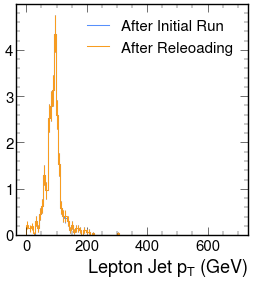

In [11]:
print(results.keys())
print(results['cutflow'][channels_new[0]].print_table())
print()

print(results.keys())
print(results['cutflow'][channels_new[0]].print_table(unweighted=True))
print()

print(f"Histograms generated: {len(results['hists'])}")
print(results['hists'].keys())

import mplhep as hep
hist_obj = results['hists']["lj_pt"]
hist_data = hist_obj.hist
hist_1d = hist_data[channels_new[0], :] 
hist_list.append(hist_1d)

plt.subplots(1,1,figsize=(6,6))
plt.subplot(1,1,1)
hep.histplot(hist_list) 
plt.legend(["After Initial Run", "After Releoading"])
plt.show()

In [12]:
# Compare Original vs Reloaded Counts
orig_count = results_original["cutflow"][channels[0]].cut_breakdown()[-1]
reload_count = results["cutflow"][channels_new[0]].cut_breakdown()[-1]

print(f"Original Yield: {orig_count}")
print(f"Reloaded Yield: {reload_count}")

if abs(orig_count - reload_count) < 1e-5:
    print("SUCCESS: Yields are identical!")
else:
    print("WARNING: Yields differ!")

Original Yield: 11.750329971313477
Reloaded Yield: 11.750329971313477
SUCCESS: Yields are identical!
